# ¡Hola Martin! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


------

<div class="alert alert-block alert-danger">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Martín, hiciste un buen trabajo en la preparación inicial de los datos, lo cual es una base muy importante para cualquier análisis, y se nota que has sido cuidadoso con aspectos como la limpieza y estandarización de columnas.

Por otro lado veo que tienes dificultades con la selección e interpretación de las gráficas. Visualizar los datos facilita su comprensión, permite identificar patrones o comportamientos rápidamente, y mejora considerablemente el análisis. Incorporar este tipo de recursos no solo enriquece el trabajo, sino que también lo hace más claro y útil para quienes deben tomar decisiones basadas en esos datos. Te comparto la siguiente página donde podrás aprender a seleccionar el mejor tipo de gráfico de acuerdo a la naturaleza de tus datos: [Data to Viz](https://www.data-to-viz.com/)

Revisa el enlace que te comparti para aprender a seleccionar gráficos, e intenta avanzar en tu proyecto. Si aún te sientes perdido podemos solicitar una tutoria para aclarar las dudas que tengas al respecto.

No debes desanimarte, esto hace parte del proceso de aprendizaje, estoy seguro que podrás avanzar en el desarrollo de este caso de estudio.

Estaré atento a tu próxima iteración 👀

</div>

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

¡Martin buen trabajo con los ajustes! Tu proyecto ahora cumple con todos los objetivos propuestos. Estoy seguro de que lo que aprendiste aquí te será muy útil más adelante. 

¡Éxito en tu próximo sprint! 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

In [4]:
games = pd.read_csv('../games.csv')
columns = []
for name in games.columns:
    name = name.lower()
    columns.append(name)
games.columns = columns
games['year_of_release'] = games['year_of_release'].astype('float64') #cambio agregado
games['year_of_release'] = games['year_of_release'].astype('Int64')
games['user_score'] = games['user_score'].replace('tbd', np.nan)
games['user_score'] = games['user_score'].astype('float64')
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 1.4 MB


Hasta aquí he cambiado lo que se ha solicitado. El bucle for para cambiar las clumnas por sus versiones en minusculas, luego los tipos de datos en las columnas: años a enteros, y la de calificacion de usuario a float (era object), cambiarlo requirió que reemplace los valores "tbd" que segun la ia de la plataforma significa "to be determined", eso es nuevo para mi pero de todas formas ese dato es un ausente en terminos estadisticos asi que lo reemplace con NaN para que no interfiera con los calculos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Has realizado una buena preparación inicial de los datos: estandarizaste los nombres de las columnas, limpiaste los valores no numéricos en `'user_score'` y realizaste las conversiones de tipo de datos necesarias. 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Una recomendación sería manejar posibles errores al convertir `'year_of_release'` a entero, ya que si existen valores nulos (`NaN`), esto puede generar errores. Podrías considerar convertir primero a tipo float y luego aplicar `.astype('Int64')`, que permite nulos.


</div>

</div>

In [5]:
#calculando ventas totales
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


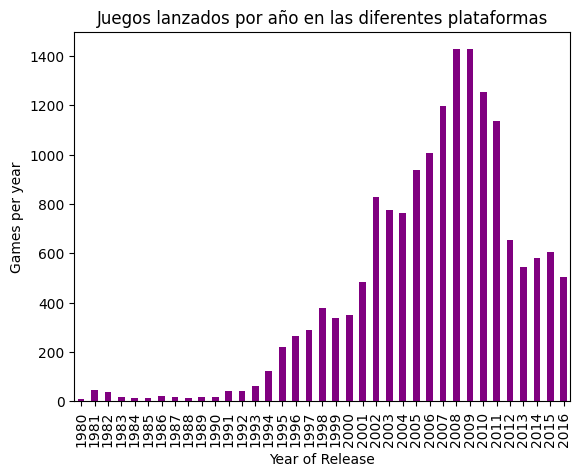

In [6]:
games_per_year = games.groupby(['year_of_release'])['name'].count()
games_per_year.plot(kind='bar', color='purple')
plt.title('Juegos lanzados por año en las diferentes plataformas')
plt.xlabel('Year of Release')
plt.ylabel('Games per year')
plt.show()

<div class="alert alert-block alert-info">
<b>Me cuesta un poco analizar este gráfico, pienso que-y tratando de no dejarme llevar por mi conocimiento previo-el comportamiento que tiene un pico en los años 2008 y 2009 representa que los usuarios estan siendo mas selectivos con los productos que compran y eso podria explicar el decenso e en ventas de los ultimos años, asi que eso daria pie a que un analisis de cuales son las plataformas mas adecuadas para sacar nuevos juegos es prioritario debio a que tomar esa decision a la ligera podria hacernos formar parte de la estadistica de ventas bajas.</b> <a class=“tocSkip”></a>
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Los resultados son correctos, pero ¿Qué información podemos obtener de estos datos? Incluye tu análisis desde una perspectiva empresarial, considerando el contexto del caso de estudio

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Tu análisis es adecuado, una forma adicional de verlos es que la gráfica muestra un crecimiento hasta 2008-2009, seguido de una caída en lanzamientos. Esto podría deberse al éxito de consolas como PS3 y Xbox 360, y luego a cambios en la industria: más enfoque en calidad, auge de juegos móviles, distribución digital o la crisis de 2008.

</div>

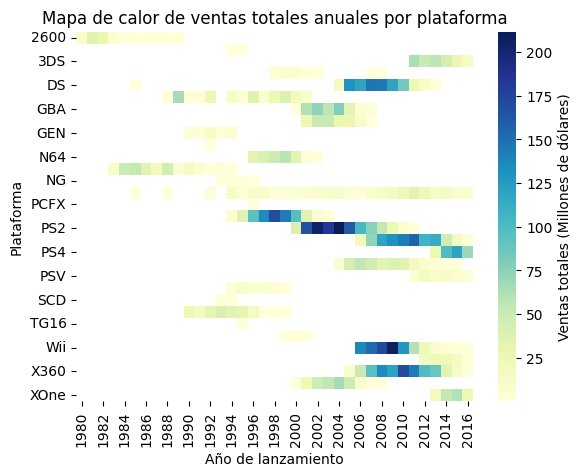

In [7]:
games_per_platform = games.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

year_list = games['year_of_release'].unique()


games_per_platform_pivot = games_per_platform.pivot(index='year_of_release', columns='platform', values='total_sales')
sns.heatmap(games_per_platform_pivot.T, cmap="YlGnBu", cbar_kws={'label': 'Ventas totales (Millones de dólares)'}) 
plt.xlabel('Año de lanzamiento')
plt.ylabel('Plataforma')
plt.title('Mapa de calor de ventas totales anuales por plataforma')
plt.show()
#sns.set_style('white')
#sns.kdeplot(data=games_per_platform_pivot, x='year_of_release', y='platform')


<div class="alert alert-block alert-info">
Aquí pensé en poner un contour plot 2D, supongo que hubiera servido pero pienso que este heatmap funciona bastante bien para tener una idea general de lo que queremos saber
</div>


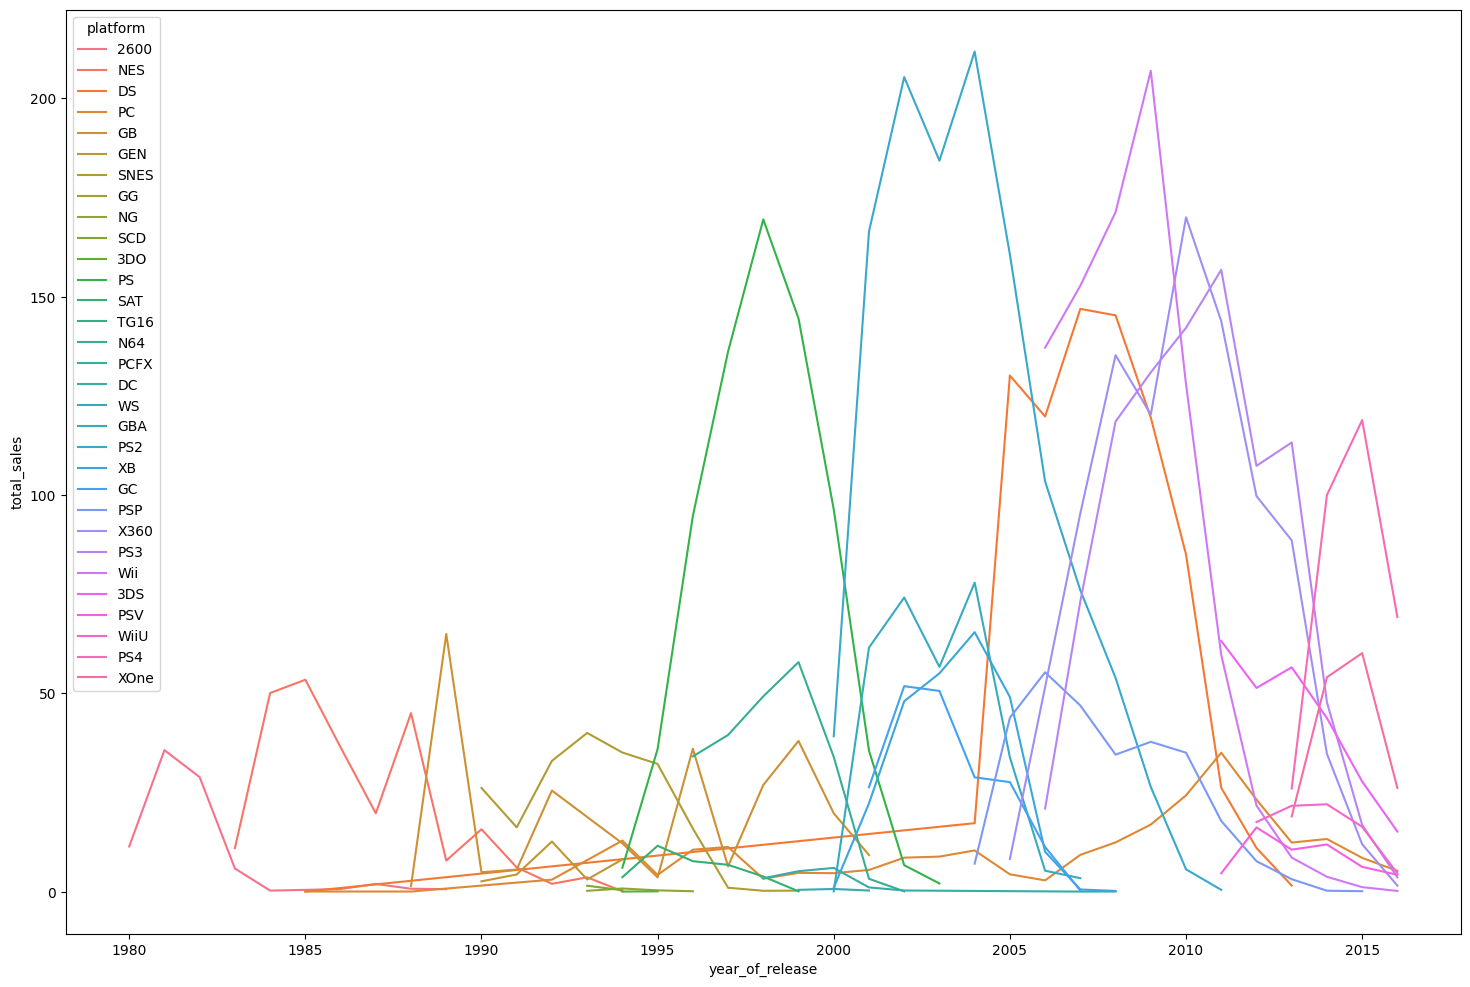

In [8]:

plt.figure(figsize=(18,12))
sns.lineplot(data=games_per_platform, x='year_of_release', y='total_sales', hue='platform')
plt.show()



<div class="alert alert-block alert-info">
Este gráfico lo hice para ver si era más ilustrativo, diria que en este caso me quedo con el heatmap
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Ambos tipos de gráficos pueden complementarse, además sirven para confirmar que cada generación de consolas tiene un ciclo de vida con un período de auge y una posterior caída, lo que sugiere que el éxito de un videojuego está fuertemente vinculado al momento en el que es lanzado dentro de ese ciclo

</div>

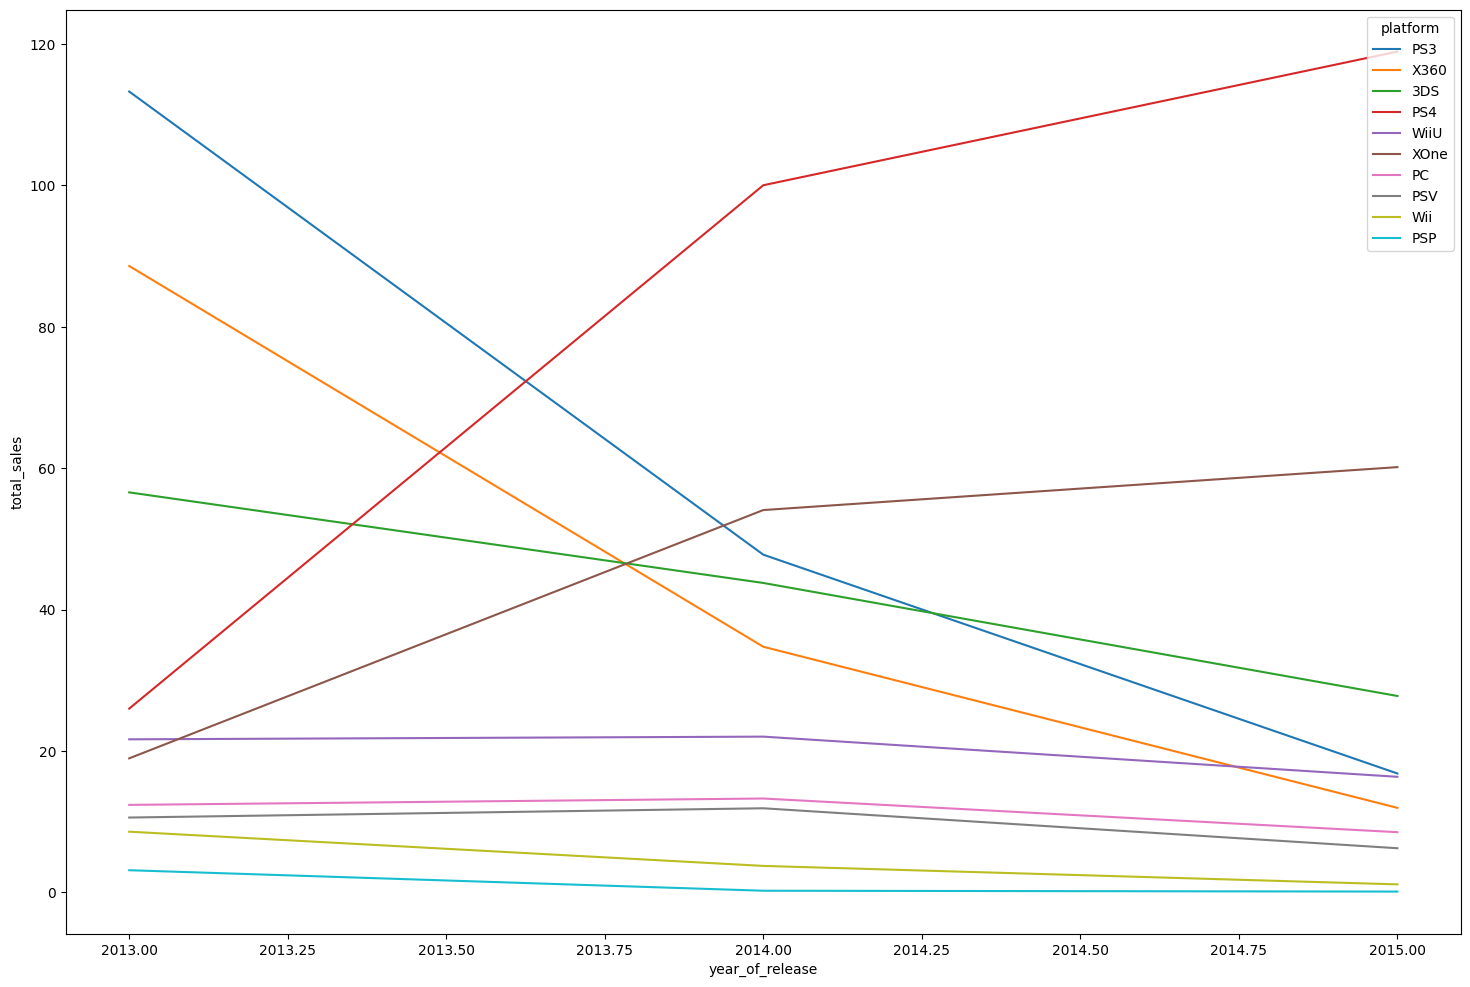

In [9]:
#filtramos por año
games_relevant = games[(games['year_of_release'] > 2012) & (games['year_of_release'] != 2016)] #excluyo el 2016 porque se mencionó que tiene datos incompletos
games_relevant_per_platform = (games_relevant.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index())
games_relevant_per_platform_sorted = games_relevant_per_platform.sort_values(['year_of_release', 'total_sales'], ascending=[True, False])
top_10_per_year = games_relevant_per_platform_sorted.groupby(['year_of_release']).head(10)
plt.figure(figsize=(18,12))
sns.lineplot(data=top_10_per_year, x='year_of_release', y='total_sales', hue='platform')
plt.show()

#years = sorted(top_10_per_year['year_of_release'].unique())
#pieces = np.array_split(years, 3)

#for i, piece in enumerate(pieces, start=1):
#    top_10_per_year_piece = top_10_per_year[top_10_per_year['year_of_release'].isin(piece)]

#    if top_10_per_year_piece.empty:
#        print(uwu)
#        continue
    
#    plt.figure(figsize=(18,7))
#    sns.lineplot(data=top_10_per_year_piece,  x='year_of_release', y='total_sales', hue='platform')
#    min_range = top_10_per_year_piece['year_of_release'].min()
 #   max_range = top_10_per_year_piece['year_of_release'].max()
#    plt.xticks(rotation=90)
#    plt.show()
#plt.figure(figsize=(18, 7))
#sns.barplot(data=top_10_per_year, x='year_of_release', y='total_sales', hue='platform')
#plt.tight_layout()
#plt.xticks(rotation=90)
#plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Este tipo de gráficos no es el más apropiado para representar los datos, ya que tenemos varias plataformas, entonces no es tan fácil identificar patrones en el comportamiento. Te recomiendo usar un gráfica de lineas, para ver la evolución de las ventas año a año

</div>


<div class="alert alert-block alert-info">
En esta ultima gráfica he decidido filtrar hasta desde el 2012 en lugar del 2000 porque habia muchas plataformas que llegaron a cero en esos años y ademas de eso en este 'pequeño' lapso de tiempo es mas ilustrativa la imagen
</div>
Por cierto en esto siento que tengo el sesgo de pensar que ahora las computadoras son mas atractivas para los videojuegos aunque en la grafica el comportamiento es lo contrario, asi que por ahora me voy decantando por considerar que solo PS4 y XOne que parecen ser las mejores para ese año

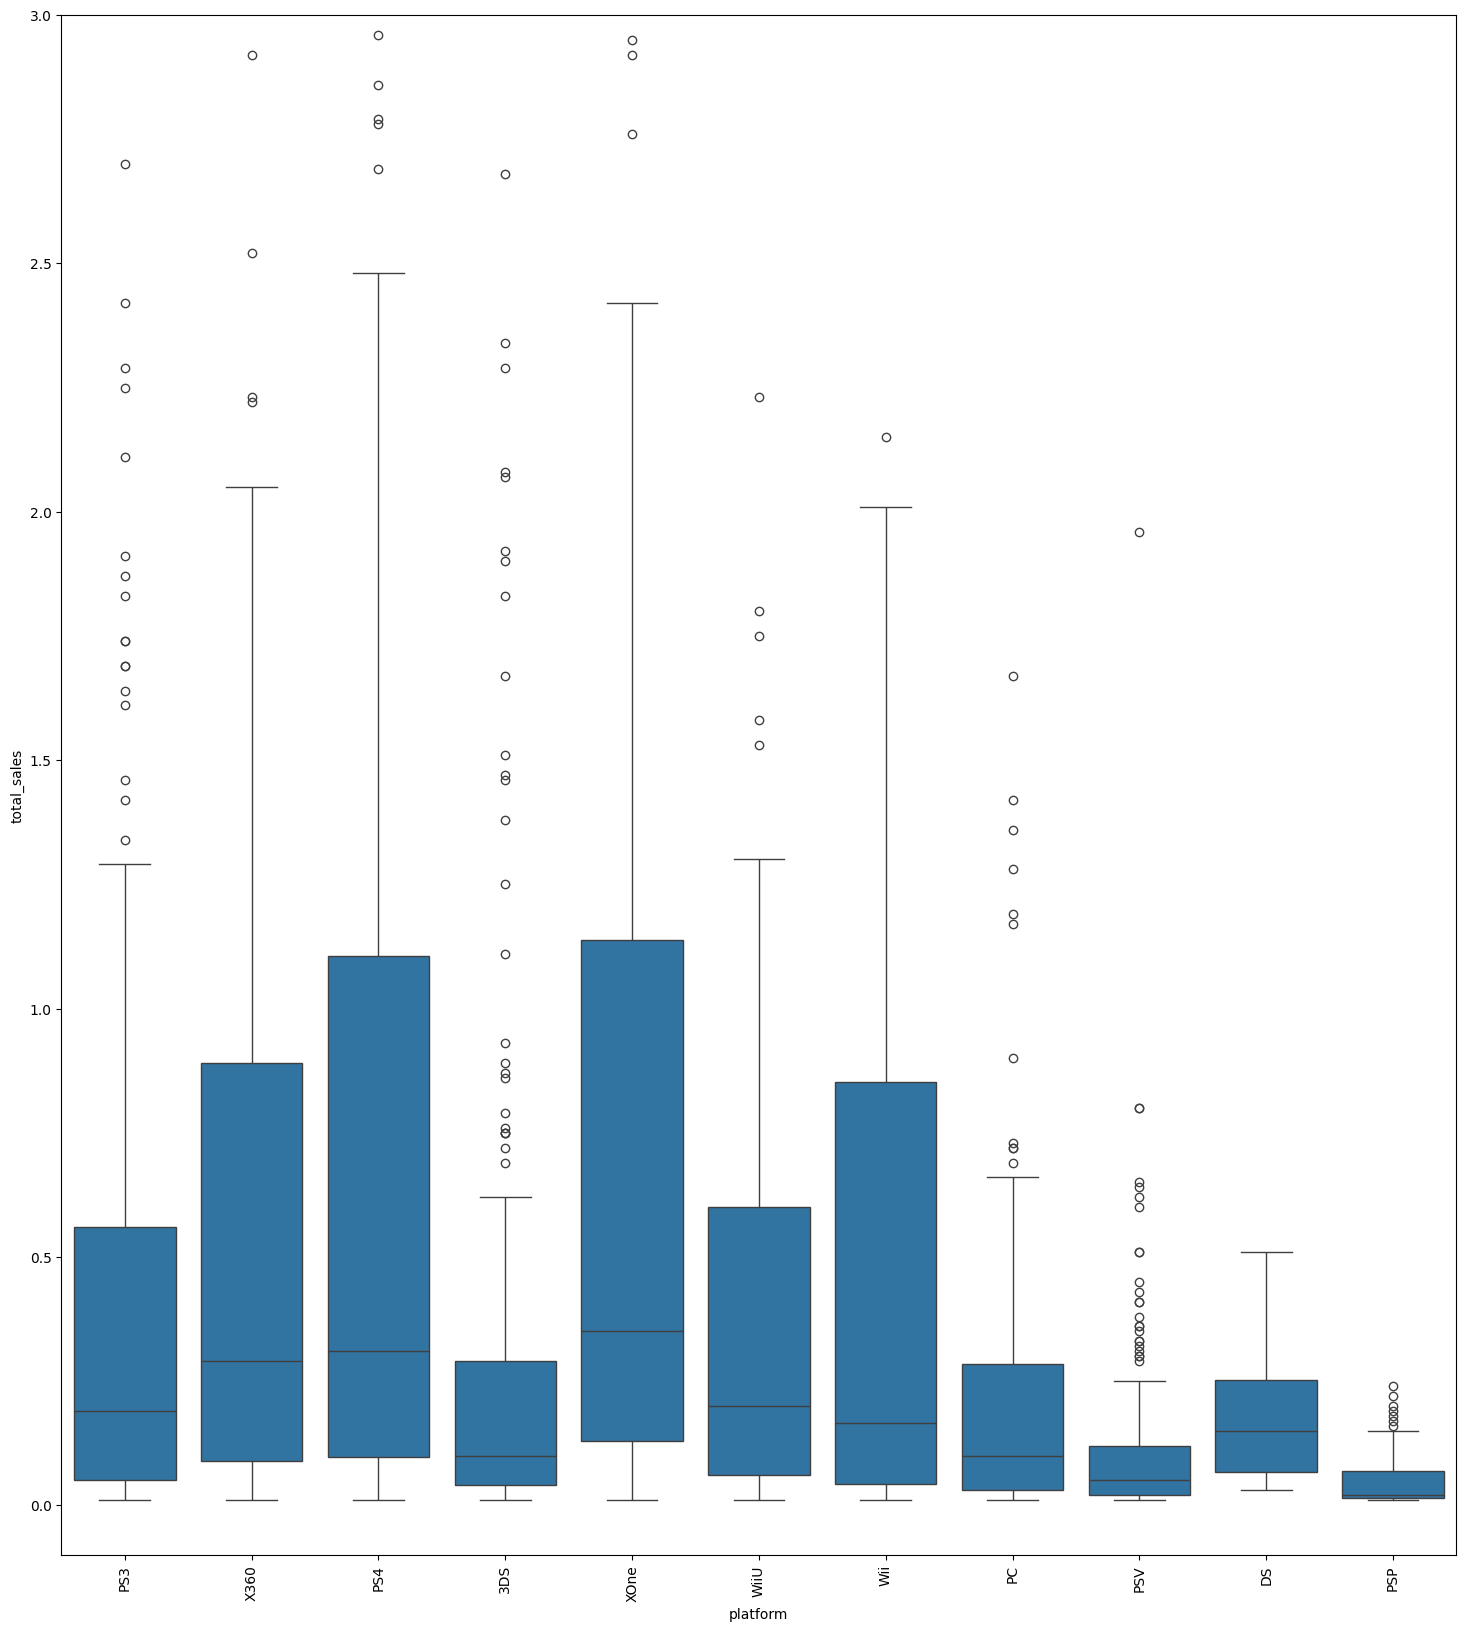

In [10]:
plt.figure(figsize=(18, 20))
sns.boxplot(x='platform', y='total_sales', data=games_relevant)
plt.xticks(rotation=90)
plt.ylim(-0.1,3)
plt.show()

<div class="alert alert-block alert-info">
aqui en lugar de poner los boxplot en logaritmico decidí mostrar solo las cajas como tal, la verdad no estoy seguro si dejar los outliers asi de excluidos es lo mejor pero al menos las graficas se ven mejor.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Como sugerencia, cuando tengas gráficas *box-plot* con cajas muy "estrechas" debido a la presencia de numerosos datos atípicos, considera incluir una versión adicional usando escala logarítmica o ajustando el rango del eje Y. Esto facilitará la comparación y el análisis de los datos.

</div>

Pondré todo lo que  considero relevante hasta el momento.
Primero es que no se me ocurre claranmente como usar los dattos, es decir creo tener una idea aproximada basado en los graficos de barras, a mi me gusta la historia de los videojuegs de hecho y pienso que eso me esta haciendo tener un sesgo respecto a los datos, que no se si sea un sesgo que vaya a dañar el estudio. Para mencionarlo diré que entiendo que lo de las plataformas es algo que uno debe estar actualizado, la ps3 es una consola que dejó de tener videojuegos de manera continua justo alrededor del 2015 si no me equivoco y en la grafica se puede ver claramente que sus ventas estan casi ausentes, y solo hay unas cuantas que tienen ventas relevantes los 2  ultimos años, que serian PS4 y XBox one debido a que son las consolas de generacion actual en esos años, asi que no sé si deberia considerar datos unicamente de esos años para generar un resultado confiable porque claramente la mayoria de consolas mencionadads en este dataframe ya son consideradas obsoletas o retro en el año en el que se ambienta el estudio.
por otro lado no sé como es que un diagrama de cajas me va a ayudar aqui, hice uno con los años filtrados desde el 2000 como se puede ver en el codigo (no sé si el diagrama esta bien hecho en terminos de los datos y como es que hice que el codigo los maneje pero hasta el momento pareiera ser qu casi todos estan cercanos  en los promedios  y valores outlier)
voy a ver como avanzar por el momento

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Es cierto que podemos tener sesgos respecto a nuestras propias experiencias o relación con lo datos. Pero como análistas de datos debemos evitar esto, y centrarnos en interpretar la información disponible. Para esto es clave saber cómo presentar la información, saber escober qué datos mostrar y qué tipo de gráficas usar, esto nos ayudará mucho. 



</div>

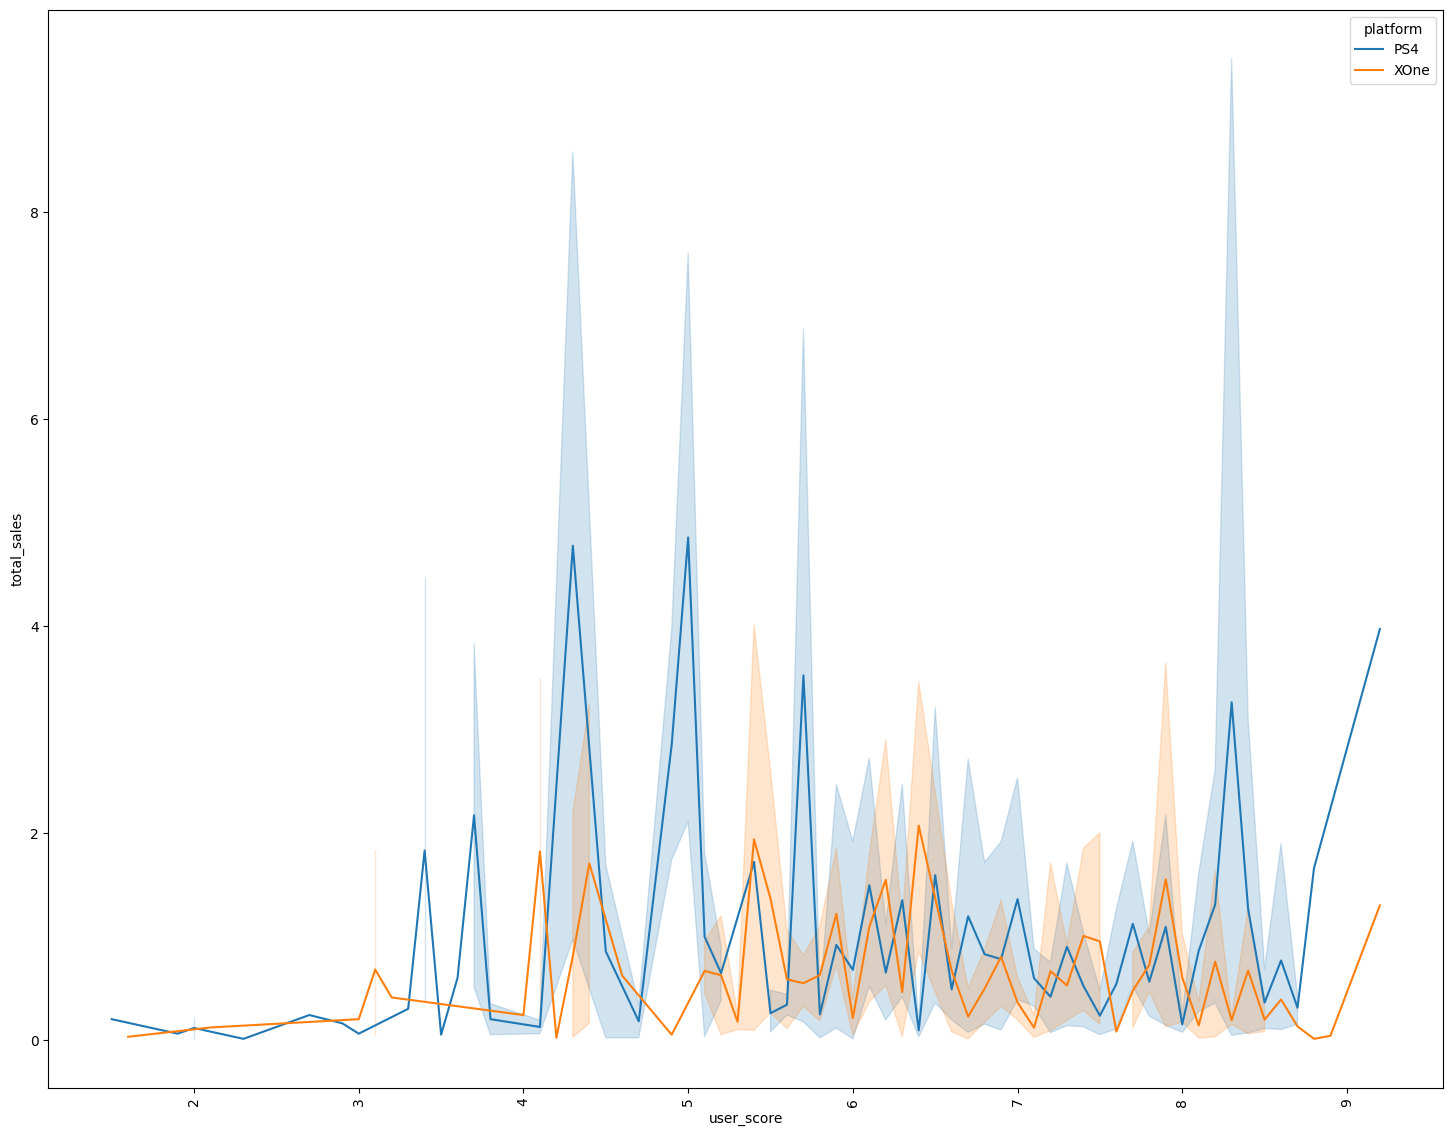

In [11]:
games_popular = games[(games['platform'] == 'PS4') | (games['platform'] == 'XOne')]
plt.figure(figsize=(18,14))
sns.lineplot(data=games_popular, x='user_score', y='total_sales', hue='platform')
plt.xticks(rotation=90)
plt.show()

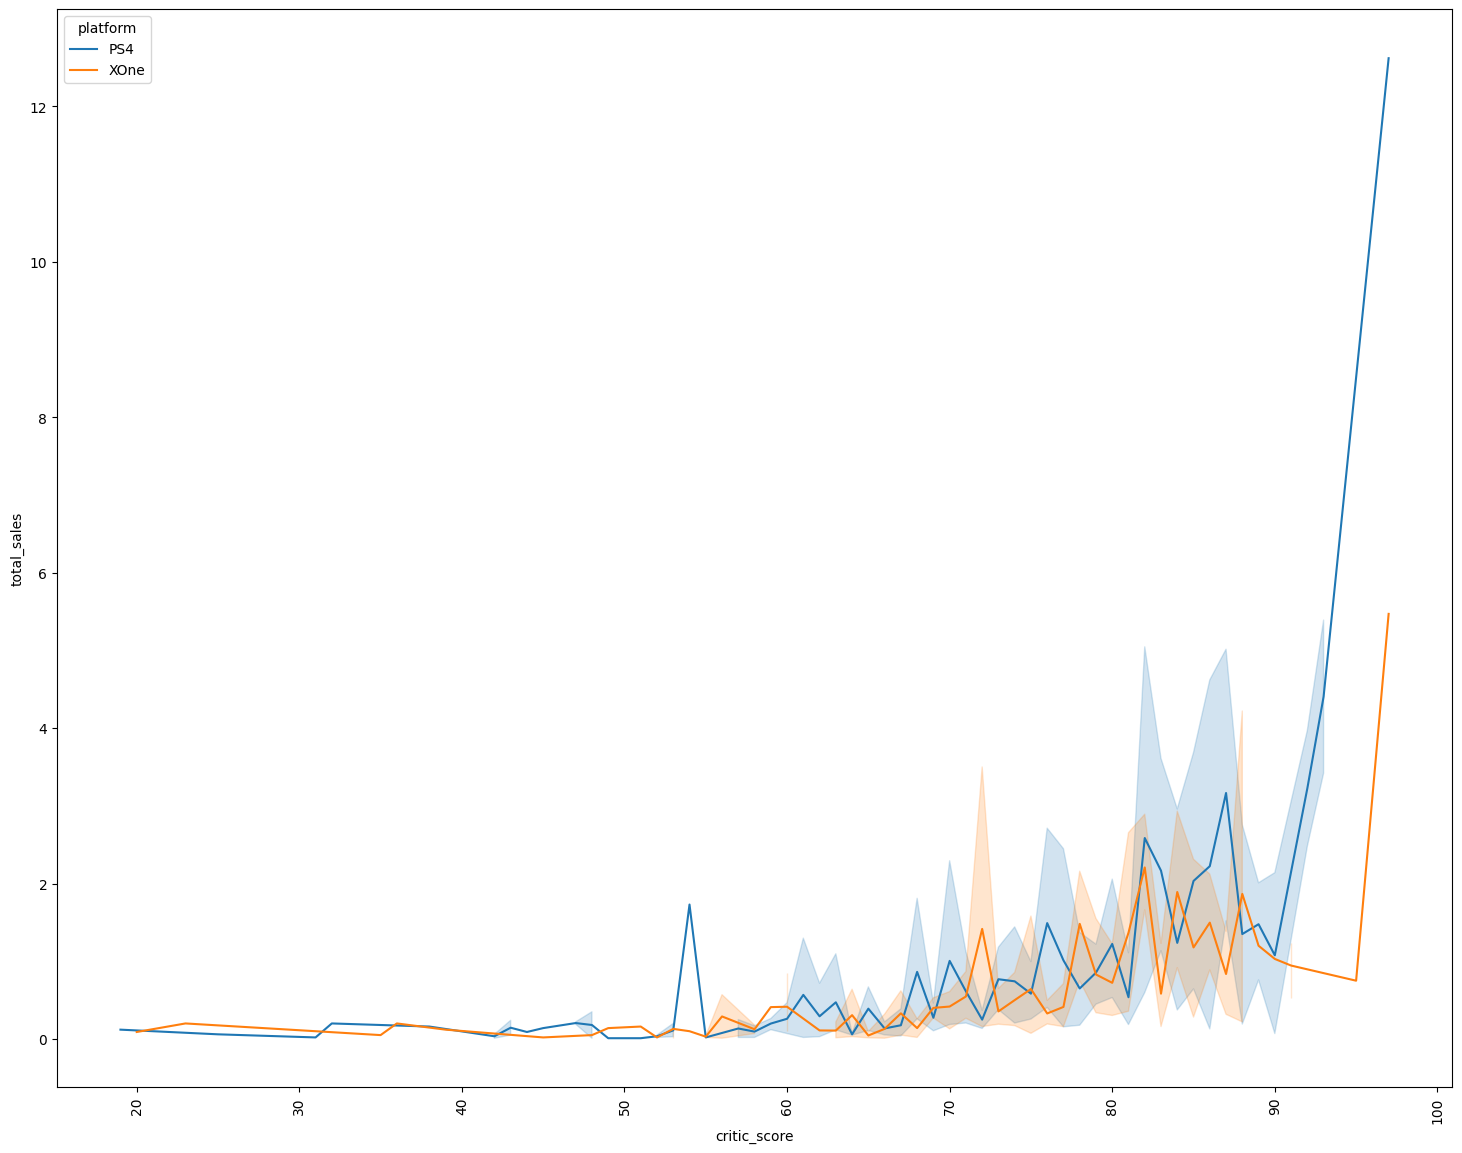

In [12]:
plt.figure(figsize=(18,14))
sns.lineplot(data=games_popular, x='critic_score', y='total_sales', hue='platform')
plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-info">
En esta parte he cambiado a graficos de lineas, creo que esta un poco mas ilustrativo, veré si me es util mas adelante
</div>


<div class="alert alert-block alert-info">
Los graficos de lineas pienso que me dan buena información, de ellos concluyto que tanto las puntuaciones de los críticos como la de los ususarios impactan en la venta de videojuegos, al menos en estas 2 plataformas
</div>


Hola, estoy tratando de avanzar, me siento algo perdido. creo que no estoy haciendo las graficas adecuadas para lo que se esta pidiendo, estas ultimaspor ejemplo se sienten poco ilustrativas y como el resto que debo  hacer depende de estas siento que estoy haciendo el avance cada vez mas dificil, no estoy seuro si estoy documentando bien y creo que si sigo asi me voy a tardar demasiado en concluir este proyecto, voy enviando sin finalizar ya 3 de estos trabajos para obtener ayuda, no se si es algo esperado pero en caso de no serlo tal vez haya otra forma de avanzar sin que sea de esta en particular. gracias de antemano.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Creo que tu mismo te has dado cuenta que el tipo de gráfica es clave para poder entender los datos. En este caso, la gráfica más apropiada es un scatter plot o gráfica de puntos, de esta forma podremos identificar tendencia entre datos.

Adicionalmente, puedes calcular numéricamente la correlación entre variables puedes usar el método `corr()` que estima por defecto la [correlación de Pearson](https://www.scribbr.com/statistics/pearson-correlation-coefficient/) entre dos variables

</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Es fundamental que, a medida que avances en tu proyecto, vayas incluyendo tus análisis e interpretaciones justo después de obtener cada resultado ya que esto permite darle claridad y coherencia a tu trabajo. Es decir, usar una estructura como:

```python
+ Gráfica_1 o Tabla_1
+ Análisis de la información de la gráfica_1 o tabla_1

+ Gráfica_2 o Tabla_2
+ Análisis de la información de la gráfica_2 o tabla_2
.
.
.

```

Este enfoque no solo facilita la comprensión de tus hallazgos, sino que también muestra tu capacidad para interpretar los datos en contexto. Al final del proyecto, podrás redactar una conclusión general que reúna y resuma de manera ordenada toda la información obtenida dándole un enfoque con relación al caso de estudio, permitiendo así cerrar el estudio con una visión integral y bien fundamentada.

</div>

In [13]:
x= games['total_sales']
y= games['user_score']
z= games['critic_score']

mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(z)
r_1, p_valor_1 = pearsonr(x[mask],y[mask])
r_2, p_valor_2 = pearsonr(x[mask],z[mask])
print('Correlacion de Pearson de las ventas totales con el puntaje de críticos:', p_valor_2)
print('Correlacion de Pearson de las ventas totales con el puntaje de los usuarios:', p_valor_1)

Correlacion de Pearson de las ventas totales con el puntaje de críticos: 3.7463495615769273e-90
Correlacion de Pearson de las ventas totales con el puntaje de los usuarios: 1.0435393360455634e-13


In [14]:
def read_pearson(p_value, variable_1, variable_2):
    print(f'para las variables {variable_1} y {variable_2}')
    if p_value == 0:
        print('Las variables no tienen una correlación lineal y no se puede concluir que no tengan una relación no lineal')
    elif p_value > 0:
        print('Las variables tienen una correlacion lineal positiva que es tan fuerte como el valor se acerca a 1')
    elif p_value < 0:
        print('Las variables tienen una correlacion lineal negativa que es tan fuerte como el valor se acerca a -1')

In [15]:
read_pearson(p_valor_1, 'ventas totales', 'puntaje de los usuarios')
read_pearson(p_valor_2, 'ventas totales', 'puntaje de los críticos')

para las variables ventas totales y puntaje de los usuarios
Las variables tienen una correlacion lineal positiva que es tan fuerte como el valor se acerca a 1
para las variables ventas totales y puntaje de los críticos
Las variables tienen una correlacion lineal positiva que es tan fuerte como el valor se acerca a 1


En esta sección voe que ambas correlaciones son positivas pero a grandes rasgos nula, podría concluir visualmente que en efecto los puntajes afectan las ventas de los videojuegos, ya sea en critica o por los usuarios.
Pero la medida de correlacion de Pearson indica que esta relacion es casi inexistente al menos de manera lineal.

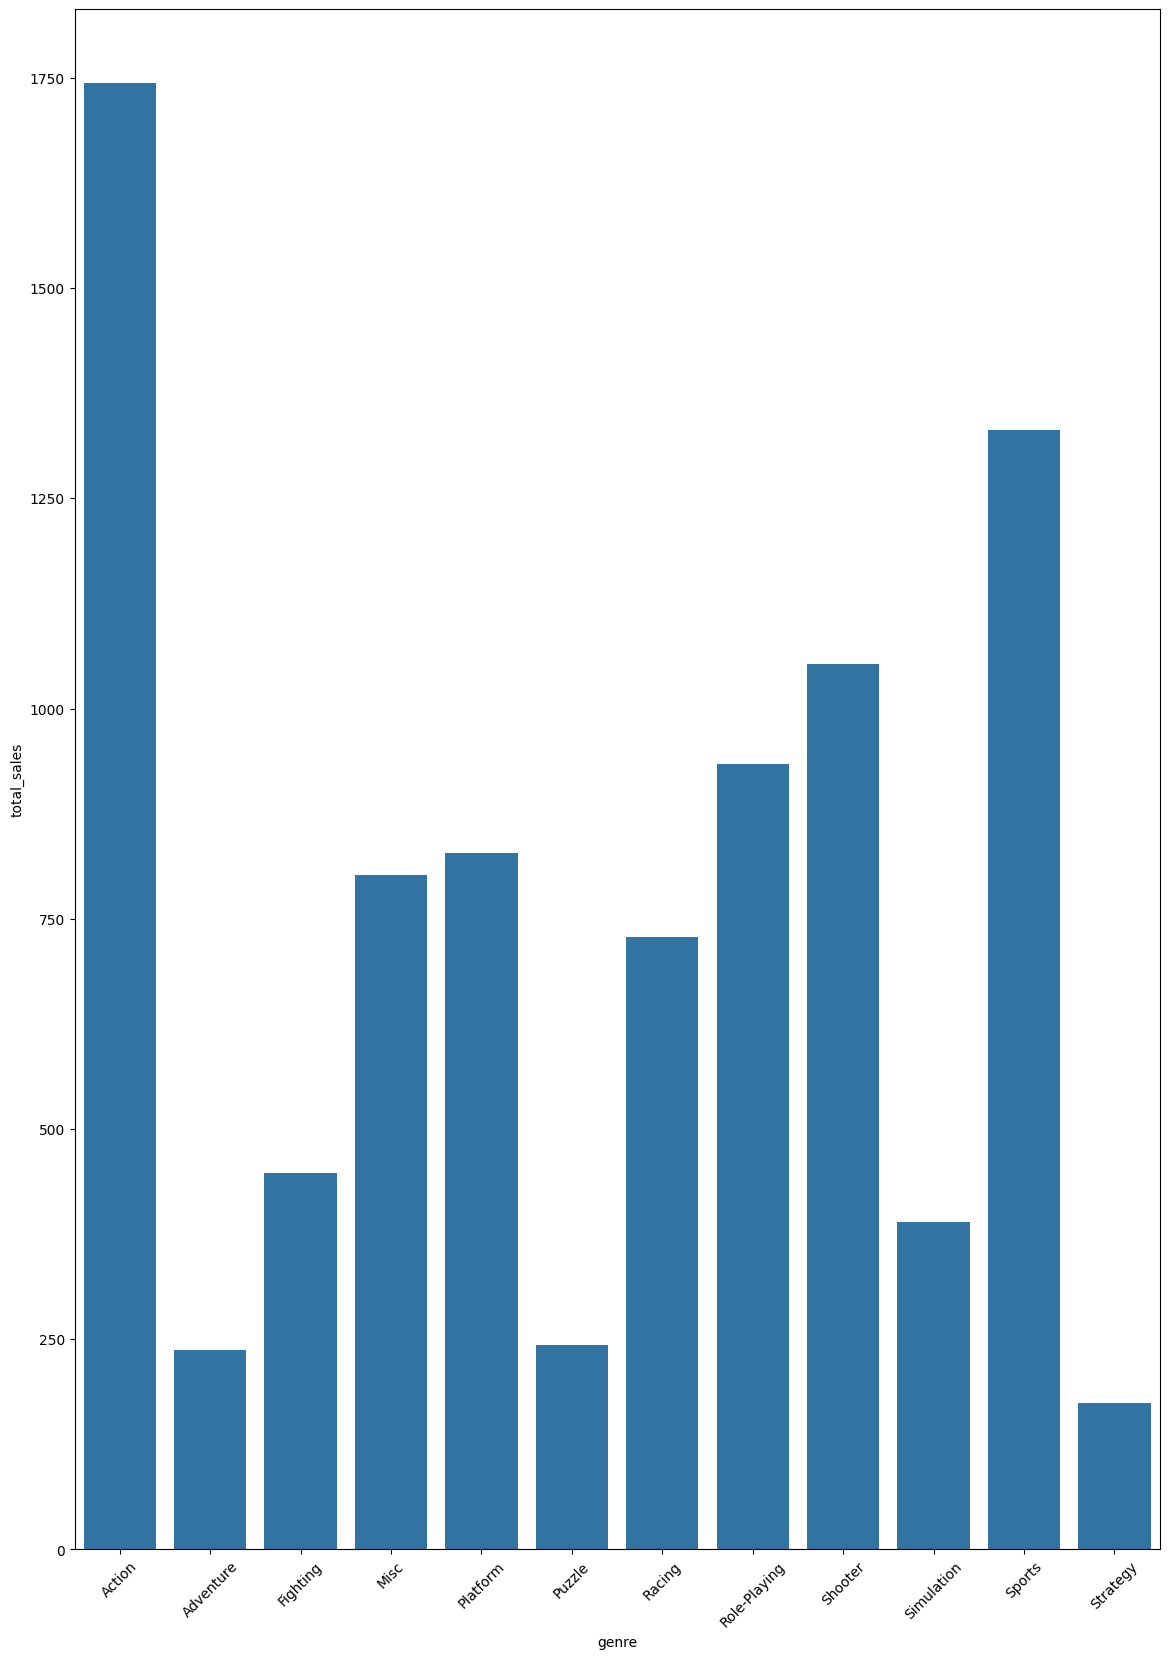

In [16]:
games_genre = games.groupby(['genre'])['total_sales'].sum().reset_index()
plt.figure(figsize=(14,20))
sns.barplot(data=games_genre, x='genre', y='total_sales')
plt.xticks(rotation=45)
plt.show()

Para este ultimo grafico seria facil tratar de asumir que los generos de accion y deportes son los mas rentables pero creo que haria falta información mas detallada para llegar a esa conclusion, el costo de producción o el nicho, pienso que puede que por haber mas oferta de cierto tipo hay mas ventas de ese mismo asi que con solo este gráfico no me basta para concluir algo mas general pero me da una idea basica de a donde me puedo dirigir

In [17]:

games_na_platform = games.groupby(['platform'])['na_sales'].sum().reset_index()
games_eu_platform = games.groupby(['platform'])['eu_sales'].sum().reset_index()
games_jp_platform = games.groupby(['platform'])['jp_sales'].sum().reset_index()

games_na_genre = games.groupby(['genre'])['na_sales'].sum().reset_index()
games_eu_genre = games.groupby(['genre'])['eu_sales'].sum().reset_index()
games_jp_genre = games.groupby(['genre'])['jp_sales'].sum().reset_index()

games_na_critic = games.groupby(['critic_score'])['na_sales'].sum().reset_index()
games_eu_critic = games.groupby(['critic_score'])['eu_sales'].sum().reset_index()
games_jp_critic = games.groupby(['critic_score'])['jp_sales'].sum().reset_index()



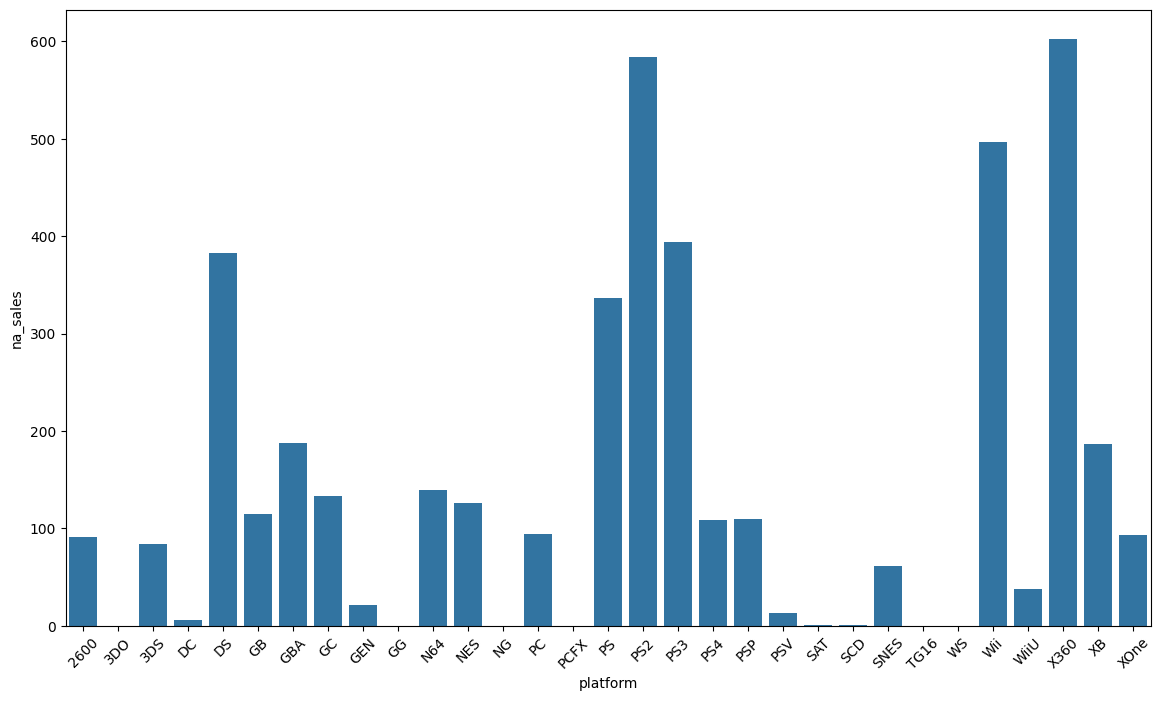

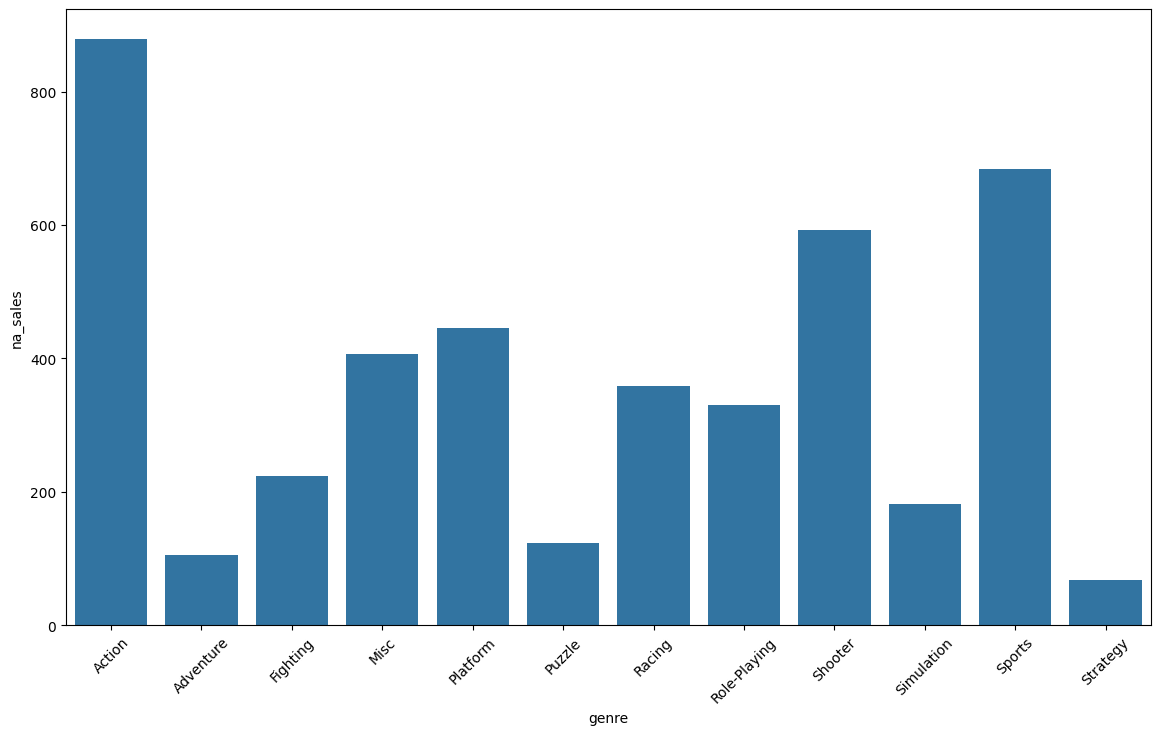

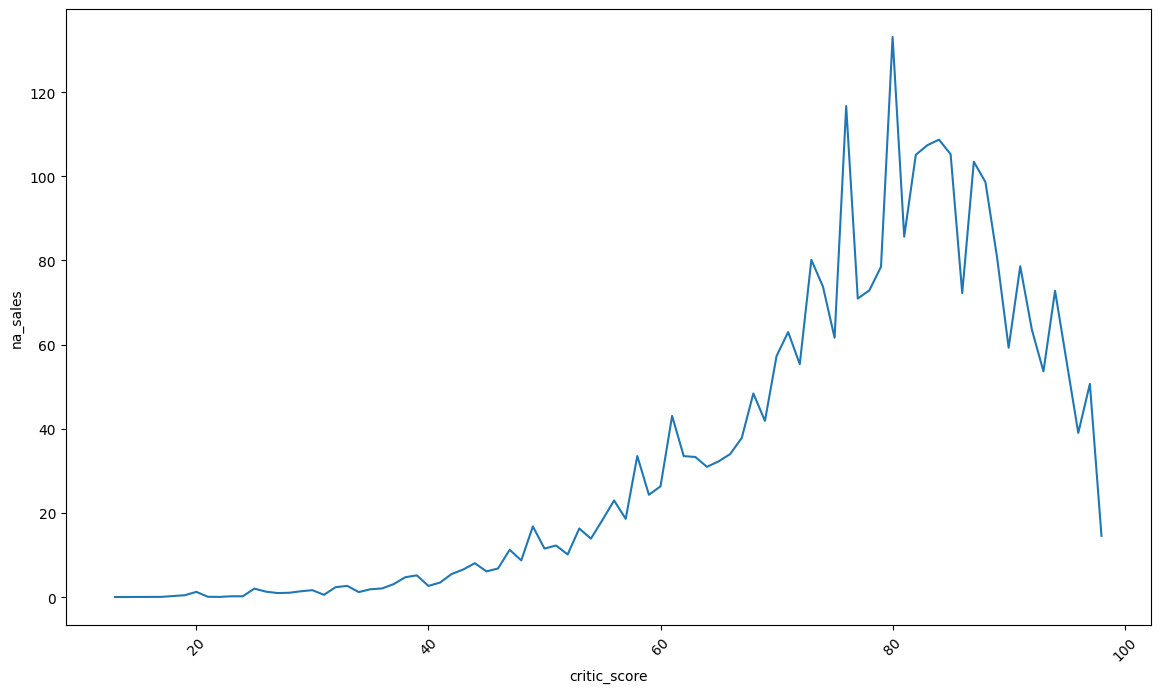

In [18]:
plt.figure(figsize=(14,8))
sns.barplot(data=games_na_platform, x='platform', y='na_sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,8))
sns.barplot(data=games_na_genre, x='genre', y='na_sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,8))
sns.lineplot(data=games_na_critic, x='critic_score', y='na_sales')
plt.xticks(rotation=45)
plt.show()

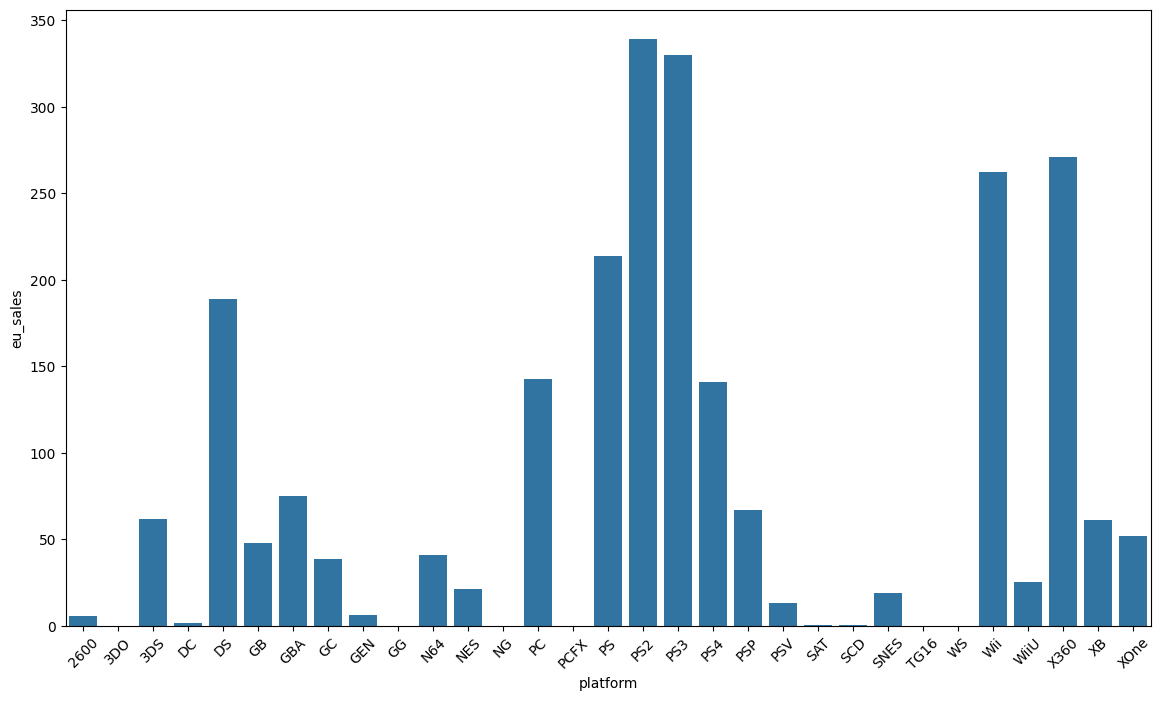

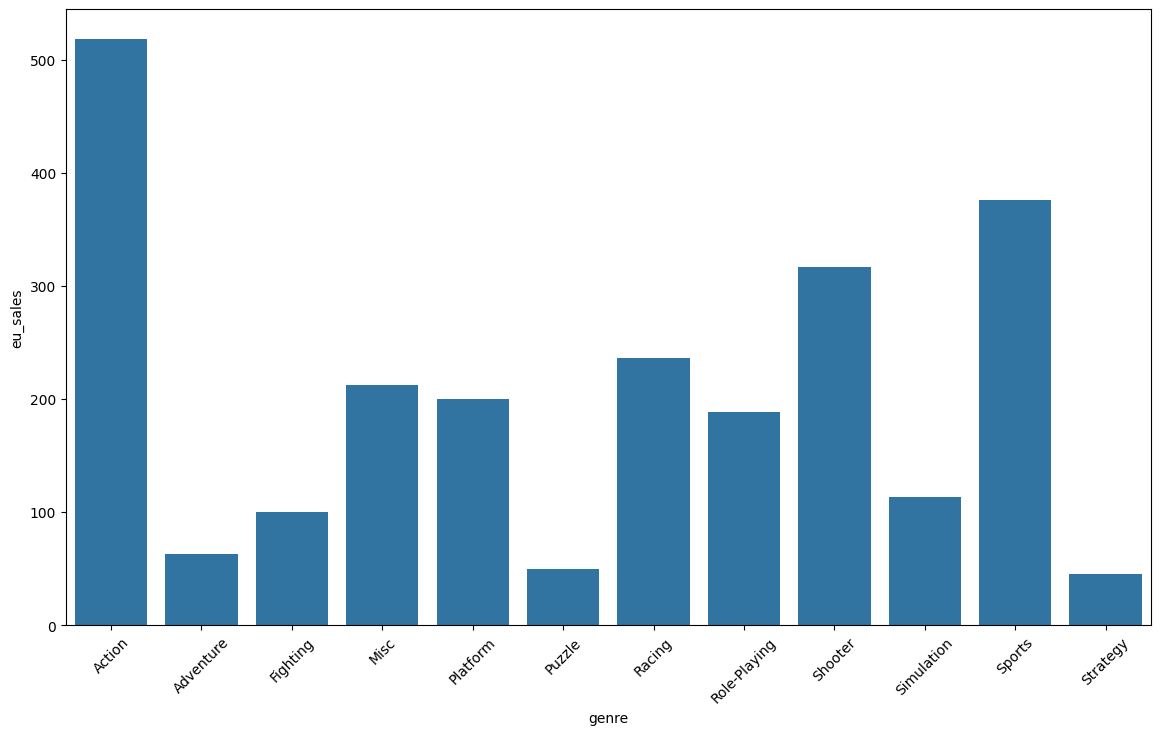

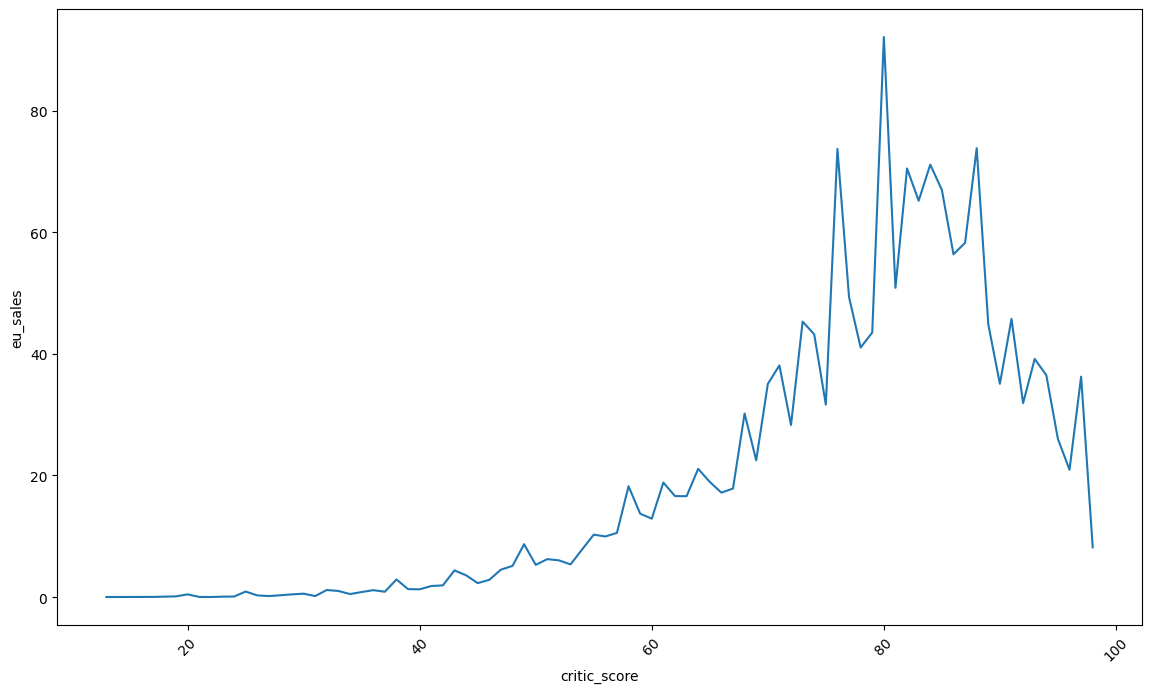

In [19]:
plt.figure(figsize=(14,8))
sns.barplot(data=games_eu_platform, x='platform', y='eu_sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,8))
sns.barplot(data=games_eu_genre, x='genre', y='eu_sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,8))
sns.lineplot(data=games_eu_critic, x='critic_score', y='eu_sales')
plt.xticks(rotation=45)
plt.show()

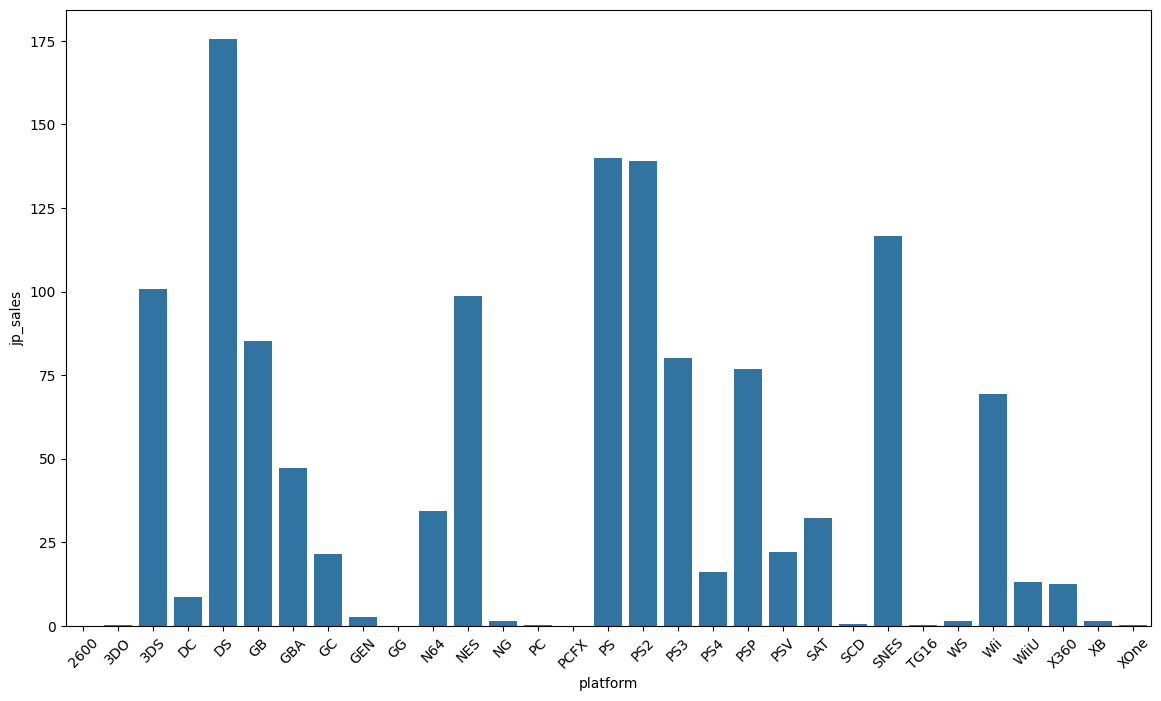

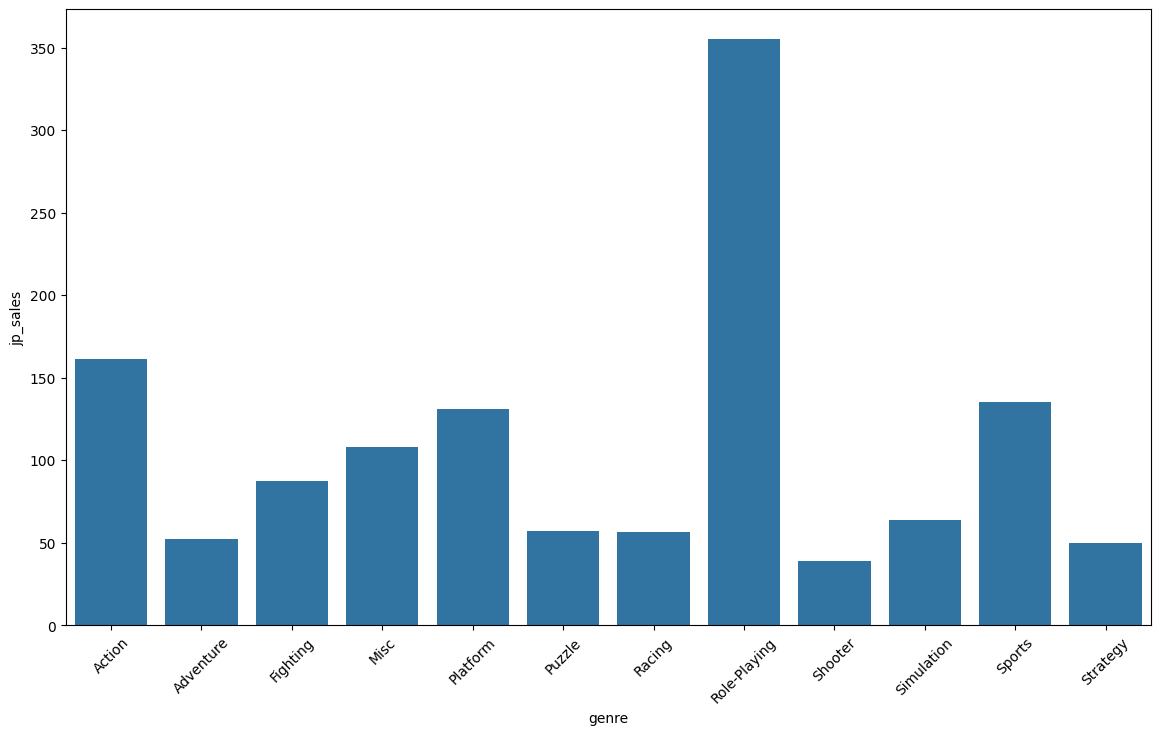

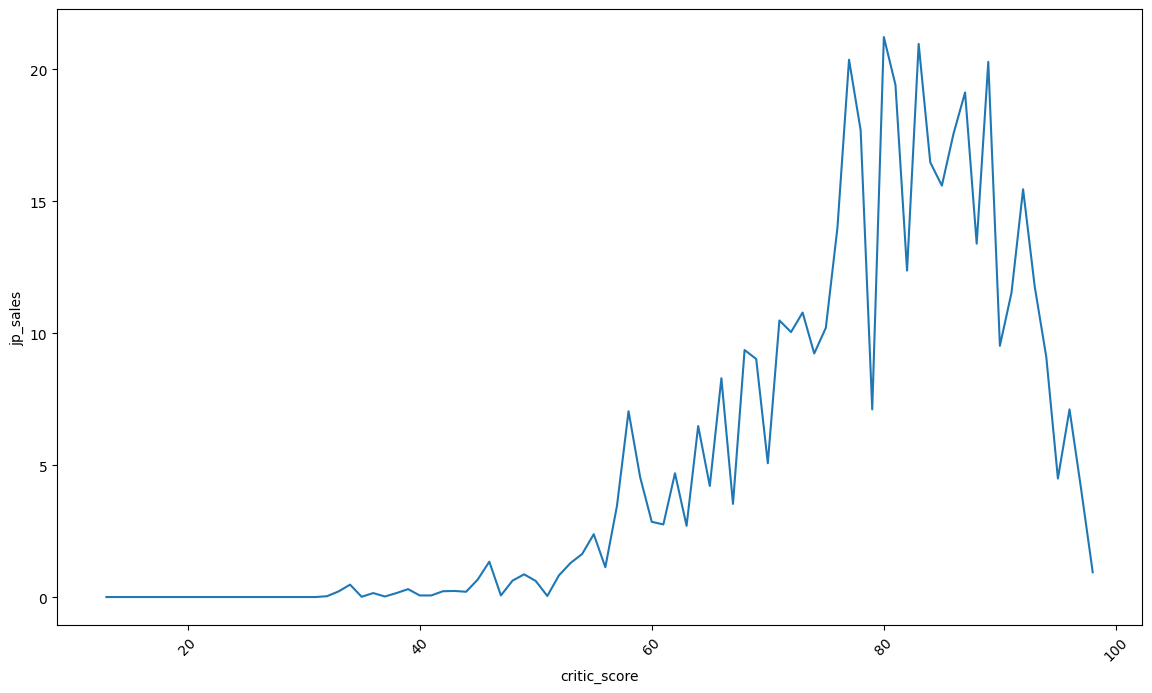

In [20]:
plt.figure(figsize=(14,8))
sns.barplot(data=games_jp_platform, x='platform', y='jp_sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,8))
sns.barplot(data=games_jp_genre, x='genre', y='jp_sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,8))
sns.lineplot(data=games_jp_critic, x='critic_score', y='jp_sales')
plt.xticks(rotation=45)
plt.show()

Hablando de la segregación por género puedo ver que las principales son acción y deportes en la unión europea y en américa del norte, pero en japon eso cambia a los juegos de Rol y tiene como segundo y tercer lugar a los mismos que en las otras 2 zonas.  
Teniendo en cuenta la separación por plataforma las cosas cambian ligeramente en UE y NA, teniendo como plataformas principales PS y XBOX, siendo que en JP destaca mucho más la DS o plataformas como la NES o las de PS.  
Finalmente en crítica hay una correlacion bastante uniforme en las 3, se ve que hay una especie de distribución cercana a la normal con el centro en la zona entre 75 y 85 de puntaje de crítica especializada.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Martin has logrado identificar claramente las diferencias entre América del Norte, Europa y Japón, no solo en términos de plataformas y géneros predominantes, sino también en la influencia de las clasificaciones ESRB, lo que refleja tu capacidad para conectar datos con tendencias culturales y de comportamiento. 

</div>

In [21]:
games_ttest_critic_1 = games[(games['platform'] == 'PC')]['critic_score']
games_ttest_critic_1 = games_ttest_critic_1[~np.isnan(games_ttest_critic_1)]
games_ttest_critic_2 = games[(games['platform'] == 'XOne')]['critic_score']
games_ttest_critic_2 = games_ttest_critic_2[~np.isnan(games_ttest_critic_2)]
games_ttest_genre_1 = games[(games['genre'] == 'Sports')]['user_score']
games_ttest_genre_1 = games_ttest_genre_1[~np.isnan(games_ttest_genre_1)]
games_ttest_genre_2 = games[(games['genre'] == 'Action')]['user_score']
games_ttest_genre_2 = games_ttest_genre_2[~np.isnan(games_ttest_genre_2)]

alpha = 0.05

tstat_1, p_valor_1 = stats.ttest_ind(games_ttest_critic_1, games_ttest_critic_2)
tstat_2, p_valor_2 = stats.ttest_ind(games_ttest_genre_1, games_ttest_genre_2)
print('Prueba entre las calificaciones de críticos para las plataformas PC y Xbox One')
if p_valor_1 < alpha:
    print(f'el p_valor {p_valor_1} es menor que el umbral establecido del 5% por lo que rechazamos la hipótesis nula de esta prueba (es decir consideramos que los promedios son diferentes)')
else:
    print(f'el p_valor {p_valor_1} es mayor al umbral establecido por lo que aceptamos la hipotesis nulña de que los promedios son iguales')

print('Prueba para las calificaciones de los usuarios en los géneros accion y deportes')

if p_valor_2 < alpha:
    print(f'el p_valor {p_valor_2} es menor que el umbral establecido del 5% por lo que rechazamos la hipótesis nula de esta prueba (es decir consideramos que los promedios son diferentes)')
else:
    print(f'el p_valor {p_valor_2} es mayor al umbral establecido por lo que aceptamos la hipotesis nulña de que los promedios son iguales')

Prueba entre las calificaciones de críticos para las plataformas PC y Xbox One
el p_valor 0.008453749599635617 es menor que el umbral establecido del 5% por lo que rechazamos la hipótesis nula de esta prueba (es decir consideramos que los promedios son diferentes)
Prueba para las calificaciones de los usuarios en los géneros accion y deportes
el p_valor 0.10406951359049145 es mayor al umbral establecido por lo que aceptamos la hipotesis nulña de que los promedios son iguales


El umbral lo establecí en el 5% porque no consideré que hubiese algo en particular que haga que necesite modificar ese número que es el que se suele usar en general.  
Hice la ptueba T debido a que los datos tienen un comportamiento cercano al normal por lo que pude ver en las gráficas anteriores.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Martin aplicaste correctamente las prueba de hipótesis comparando las distribuciones dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

</div>

Conclusión general:  
Basado en los datos que he observado diria que en las regiones de america y europa hay que centrarse en los géneros de acción y deportes, en japon tambien porque representan una parte importante de las estadisticas pero deberia tener más prioridad los juegos de rol.  
Por otro lado hemos visto en esta parte final que los promedios de critica para las plataformas de xbox y PC son distintas por lo que podemos asumir que en general una plataforma tiene críticas mas altas que la otra asi que tendriamos que centrarnos en una de esas 2.  
Asimismo veo que la critica de los usuarios tiene un comportamiento mas cercano en los juegos de acción y deportes por lo que diria que en general estos generos estan a la par en popularidad (una conclusion algo vaga por la poca información pero hacia ahi nos lleva el estudio en general).  
Creo que podria haber mas que puedo hacer para complementar este estudio pero la verdad no tengo la certeza, pienso que podria extraer algo mas de informacion pero no se que tanto.  
Tambien quiero mencionar que las plataformas que deberian copnsiderarse son las de los ultimos años nada más, como la Xbox one y PS4, incluso las de generación pasada en algunos casos pero realmente eso ya esta creo que un poco por fuera de lo que uno puede concluir con los datos que se tienen en este trabajo.


<div class="alert alert-block alert-info">
Creo que pude hacer más, la verdad no sé si lo que hice es suficiente para aprobar el proyecto pero es abrumador en cierto sentido, es decir ahora solo es un ensayo pero en general este tipo de trabajo le da a uno la responsabilidad de dar pautas de como usar mucho dinero y podrian haber pérdidas muy grandes en caso de que esto no se haga bien en un escenario real.  
    Espero la revisión para saber en que puedo mejorar, gracias.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Tienes razón que el análisis que hagamos de un conjunto de datos es clave y muy determinante a la hora de tomar decisiones, es por eso que estás desarrollando las habilidades necesarias para interpretar la inforamción de la mejor manera. Te comparto algunos tips que te pueden ser útiles en tu formación


1. **Practica el pensamiento crítico:** antes de analizar, cuestiona los datos — ¿de dónde vienen?, ¿qué significan?, ¿qué sesgos pueden tener?
2. **Domina la limpieza de datos:** gran parte del análisis se basa en datos bien preparados; aprende a detectar y corregir errores, valores nulos, duplicados o inconsistencias.
3. **Ejercita la visualización:** usa herramientas herramientas de visuialización para traducir datos en insights claros y visuales.
4. **Refuerza la lógica estadística:** comprende conceptos como correlación, regresión, probabilidad y distribución para interpretar correctamente los resultados, y validar hipótesis que tengas
5. **Entender el Contexto:** En tu rol como análista de datos te vas a enfretar a datasets de áreas que tal vez no conozcas, es importante entender el contexto de los datos, lo que representan y que información nos están brindando, con eso puedo definir un estrategía para trabajar con ellos,



</div>